<a href="https://colab.research.google.com/github/dantae74/aice/blob/main/ref/brain_stroke_data_%EB%B6%84%EC%84%9D_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tabular 데이터 분류 모델 만들기
# Brain stroke(뇌졸증) data 분석
- 뇌졸증 경험 여부 판단 (0: 뇌졸증 경험없음, 1: 뇌졸증 경험있음)

In [2]:
# 라이브러리 임포트
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [4]:
# 딥러닝 라이브러리 임포트
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Flatten
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
# Tabular traindata.csv 불러오기
# df = pd.read_csv('full_data_training.csv')
# 시험에서는 위와 비슷한 명칭으로 데이터를 불러서 사용합니다.

df = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/brain_stroke_data_training.csv')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [6]:
# Tabular 데이터 정보 확인
# 위의 df와 비교하면서 값하고 Dtype이 다른 부분이 있는지 확인
# 결측치 확인, 데이터 컬럼의 용도 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB


In [ ]:
# 데이터 전처리 - 라벨 인코딩


In [9]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Apply Label Encoding to 'gender' column
df['gender'] = le.fit_transform(df['gender'])
print("Value counts after encoding 'gender':")
print(df['gender'].value_counts())

# Apply Label Encoding to 'ever_married' column
df['ever_married'] = le.fit_transform(df['ever_married'])
print("\nValue counts after encoding 'ever_married':")
print(df['ever_married'].value_counts())

Value counts after encoding 'gender':
gender
0    2907
1    2074
Name: count, dtype: int64

Value counts after encoding 'ever_married':
ever_married
1    3280
0    1701
Name: count, dtype: int64


In [10]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1
1,1,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1
2,0,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1
3,0,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1
4,1,81.0,0,0,1,Private,Urban,186.21,29.0,formerly smoked,1


In [11]:
# 결측치 확인
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [12]:
# 원 핫 인코더, object인 데이터만 분류
obj_col = df.select_dtypes('object').columns
obj_col

Index(['work_type', 'Residence_type', 'smoking_status'], dtype='object')

In [13]:
# 원 핫 인코딩
df = pd.get_dummies(df, columns=obj_col, drop_first=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,228.69,36.6,1,True,False,False,True,True,False,False
1,1,80.0,0,1,1,105.92,32.5,1,True,False,False,False,False,True,False
2,0,49.0,0,0,1,171.23,34.4,1,True,False,False,True,False,False,True
3,0,79.0,1,0,1,174.12,24.0,1,False,True,False,False,False,True,False
4,1,81.0,0,0,1,186.21,29.0,1,True,False,False,True,True,False,False


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          4981 non-null   int64  
 1   age                             4981 non-null   float64
 2   hypertension                    4981 non-null   int64  
 3   heart_disease                   4981 non-null   int64  
 4   ever_married                    4981 non-null   int64  
 5   avg_glucose_level               4981 non-null   float64
 6   bmi                             4981 non-null   float64
 7   stroke                          4981 non-null   int64  
 8   work_type_Private               4981 non-null   bool   
 9   work_type_Self-employed         4981 non-null   bool   
 10  work_type_children              4981 non-null   bool   
 11  Residence_type_Urban            4981 non-null   bool   
 12  smoking_status_formerly smoked  49

In [15]:
# feature, label 분류
labels = df['stroke']
features = df.drop('stroke', axis=1)

In [16]:
labels.value_counts()

,count
stroke,
0,4733
1,248


In [18]:
# 데이터 셋 분할 (train, val, test : 8:1:1)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42, stratify=labels)

# 테스트 데이터가 주어지는 경우 제거
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size=0.5, random_state=42, stratify=y_val)
x_train.shape, x_val.shape, y_train.shape, y_val.shape


((3984, 14), (498, 14), (3984,), (498,))

## 모델 구축 (Build the Model)

데이터 불균형 문제를 고려하여 딥러닝 모델을 구축하고 학습 가중치를 적용합니다.

In [19]:
from sklearn.utils import class_weight

# 클래스 가중치 계산 (Handling Imbalanced Data)
# 뇌졸중 환자(1)가 적으므로, 이 클래스에 더 높은 가중치를 부여하여 모델이 소수 클래스를 더 잘 학습하도록 합니다.
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(zip(np.unique(y_train), class_weights))
print(f"Class Weights: {class_weights}")

# 모델 정의
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid') # 이진 분류를 위한 Sigmoid 활성화 함수
])

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 요약
model.summary()

Class Weights: {np.int64(0): np.float64(0.526148969889065), np.int64(1): np.float64(10.06060606060606)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 모델 학습 (Train the Model)

Early Stopping을 사용하여 과적합을 방지하고, 계산된 클래스 가중치를 적용하여 불균형 데이터를 처리합니다.

In [20]:
# Early Stopping 설정: val_loss가 10 에포크 동안 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 학습
history = model.fit(
    x_train,
    y_train,
    epochs=100, # 충분히 많은 에포크 설정 (Early Stopping이 제어)
    batch_size=32,
    validation_data=(x_val, y_val),
    class_weight=class_weights, # 클래스 가중치 적용
    callbacks=[early_stopping]
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6205 - loss: 0.6774 - val_accuracy: 0.4357 - val_loss: 1.3001
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6589 - loss: 0.6253 - val_accuracy: 0.6084 - val_loss: 0.6697
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6659 - loss: 0.5957 - val_accuracy: 0.6426 - val_loss: 0.7621
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7056 - loss: 0.5900 - val_accuracy: 0.6888 - val_loss: 0.6061
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6842 - loss: 0.5482 - val_accuracy: 0.7309 - val_loss: 0.5045
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7076 - loss: 0.5654 - val_accuracy: 0.7028 - val_loss: 0.5436
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7051 - loss: 0.5395 - val_accuracy: 0.7390 - val_loss: 0.5001
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7011 - loss: 0.5440 - val_accu

## 모델 평가 (Evaluate the Model)

테스트 데이터셋을 사용하여 모델의 성능을 평가하고, 특히 불균형 데이터셋에 중요한 지표들을 확인합니다.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       474
           1       0.16      0.88      0.27        25

    accuracy                           0.77       499
   macro avg       0.58      0.82      0.57       499
weighted avg       0.95      0.77      0.83       499


ROC-AUC Score on Test Data: 0.8711


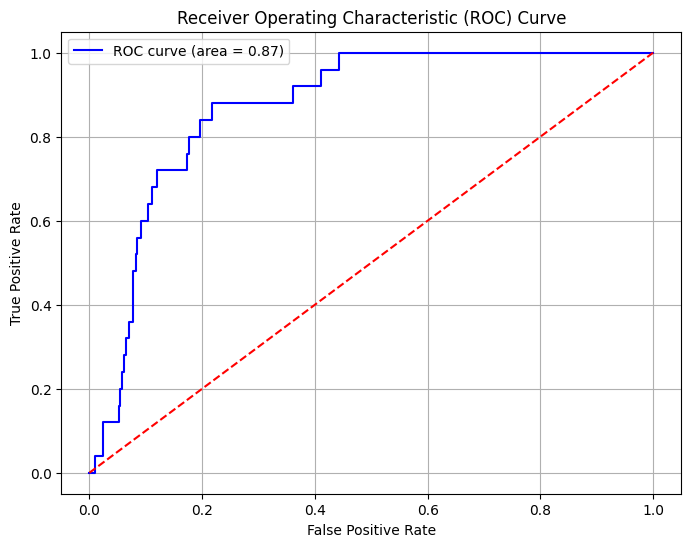

In [21]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 테스트 데이터에 대한 예측
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 평가 지표 출력
print("\nClassification Report on Test Data:")
print(classification_report(y_test, y_pred))

# ROC-AUC 스코어 계산
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score on Test Data: {roc_auc:.4f}")

# ROC Curve 시각화
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

## 모델 저장 (Save the Model)

학습된 모델을 저장합니다.

In [22]:
model.save('brain_stroke_model.keras')
print("Model saved successfully to 'brain_stroke_model.keras'")

Model saved successfully to 'brain_stroke_model.keras'


In [24]:
# 테스트 데이터 셋 읽기
test_df = pd.read_csv('https://raw.githubusercontent.com/suku-7/AICE-Pro-share/refs/heads/main/brain_stroke_data_validation.csv')
test_df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,31.555602,never smoked,1
1,Female,59.0,0,0,Yes,Private,Rural,76.15,30.242937,Unknown,1
2,Male,78.0,0,1,Yes,Private,Urban,219.84,30.698951,Unknown,1
3,Male,57.0,0,1,No,Govt_job,Urban,217.08,33.808410,Unknown,1
4,Male,58.0,0,0,Yes,Private,Rural,189.84,31.378534,Unknown,1


## 테스트 데이터 전처리 (Preprocess Test Data)

모델이 학습한 방식과 동일하게 테스트 데이터셋을 전처리합니다.

In [25]:
# 'gender' 및 'ever_married' 컬럼 라벨 인코딩
le = LabelEncoder()
test_df['gender'] = le.fit_transform(test_df['gender'])
test_df['ever_married'] = le.fit_transform(test_df['ever_married'])

# object 타입 컬럼 확인 (이미 인코딩된 gender, ever_married 제외)
obj_col_test = test_df.select_dtypes('object').columns

# 원-핫 인코딩
test_df = pd.get_dummies(test_df, columns=obj_col_test, drop_first=True)

# 'stroke' 컬럼은 타겟이므로 예측에서 제외
test_features = test_df.drop('stroke', axis=1)

# 훈련 데이터의 컬럼과 테스트 데이터의 컬럼 일치시키기
# 훈련 데이터에만 있고 테스트 데이터에 없는 컬럼은 0으로 채움
missing_cols = set(features.columns) - set(test_features.columns)
for c in missing_cols:
    test_features[c] = 0

# 테스트 데이터에만 있고 훈련 데이터에는 없는 컬럼은 제거
extra_cols = set(test_features.columns) - set(features.columns)
for c in extra_cols:
    test_features = test_features.drop(c, axis=1)

# 컬럼 순서 훈련 데이터와 동일하게 맞추기
test_features = test_features[features.columns]

test_features.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,61.0,0,0,1,202.21,31.555602,False,True,False,False,False,True,False
1,0,59.0,0,0,1,76.15,30.242937,True,False,False,False,False,False,False
2,1,78.0,0,1,1,219.84,30.698951,True,False,False,True,False,False,False
3,1,57.0,0,1,0,217.08,33.808410,False,False,False,True,False,False,False
4,1,58.0,0,0,1,189.84,31.378534,True,False,False,False,False,False,False


## 테스트 데이터로 예측 (Predict with Test Data)

전처리된 테스트 데이터셋을 사용하여 모델 예측을 수행합니다.

In [26]:
# 전처리된 테스트 데이터로 예측
test_predictions_prob = model.predict(test_features)
test_predictions = (test_predictions_prob > 0.5).astype(int)

print("Test Predictions (first 10 probabilities):\n", test_predictions_prob[:10])
print("\nTest Predictions (first 10 classes):\n", test_predictions[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Test Predictions (first 10 probabilities):
 [[0.62750775]
 [0.47618243]
 [0.8373029 ]
 [0.5657839 ]
 [0.6162177 ]
 [0.63041997]
 [0.5252324 ]
 [0.70489687]
 [0.6888059 ]
 [0.7396636 ]]

Test Predictions (first 10 classes):
 [[1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
